<a href="https://colab.research.google.com/github/liangjizhu/ArendizajeAutomatico/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción del Abandono de Empleados
# **Objetivo:**  
Predecir si un empleado abandonará la empresa (burnout/attrition) mediante diversas técnicas de aprendizaje automático.
# **Estructura del Notebook:**
1. Introducción y Objetivos
2. Exploración de Datos (EDA)
3. Preprocesamiento de los Datos (pipelines, escalado e imputación)
4. Modelado:  
    - Modelos básicos: KNN y Árboles  
    - Modelos avanzados: Regresión Logística y SVM  
5. Evaluación interna (inner) y selección del modelo final
6. Guardado del modelo final
7. Conclusiones y comentarios (incluyendo el uso de ChatGPT)
#
**Nota:** Se utiliza el dataset `attrition_availabledata_05.csv` ubicado en la carpeta `lab1/data/`.



In [1]:
# 1. Importación de librerías y configuración
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report

# Fijamos la semilla para la reproducibilidad (NIA)
SEED = 495723
np.random.seed(SEED)

## 2. Carga y Exploración de Datos (EDA)

En esta sección se carga el dataset, se exploran sus dimensiones, tipos de variables, valores faltantes y el balance de la variable objetivo.


In [4]:
# Cargar el dataset de entrenamiento
data_path = "lab1/data/attrition_availabledata_05.csv"  # Ajusta la ruta si es necesario
df = pd.read_csv(data_path)
print("Dimensiones del dataset:", df.shape)
print("\nTipos de variables:")
print(df.dtypes)

# Mostrar estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(df.describe())

# Revisar valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

Dimensiones del dataset: (2940, 31)

Tipos de variables:
hrs                        float64
absences                     int64
JobInvolvement               int64
PerformanceRating            int64
EnvironmentSatisfaction    float64
JobSatisfaction            float64
WorkLifeBalance            float64
Age                          int64
BusinessTravel              object
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeID                   int64
Gender                      object
JobLevel                     int64
JobRole                     object
MaritalStatus               object
MonthlyIncome                int64
NumCompaniesWorked         float64
Over18                      object
PercentSalaryHike            int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears          float64
TrainingTimesLastYear        int6

### Visualización del Balance de la Variable Objetivo

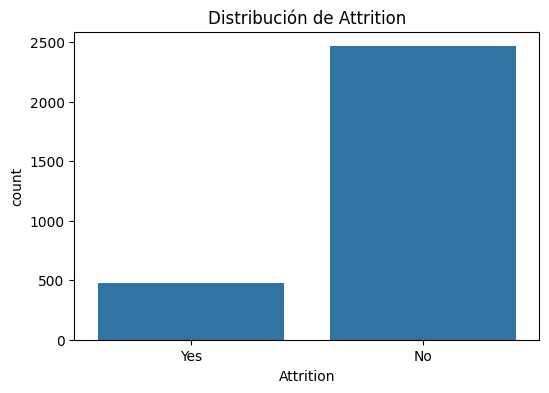

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title("Distribución de Attrition")
plt.show()

## 3. Preprocesamiento de los Datos
Se prepara un pipeline para el preprocesamiento que incluya imputación (estrategia mediana) y escalado (se usa StandardScaler, pero se pueden probar otros).


In [6]:
# Seleccionar columnas numéricas (excluyendo IDs o columnas que no se desean transformar)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Supongamos que 'EmployeeID' y 'EmployeeCount' no se quieren procesar
cols_excluir = ['EmployeeID', 'EmployeeCount']
num_cols = [col for col in num_cols if col not in cols_excluir]

# Definir el pipeline
preprocessing_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Aplicar el pipeline a las columnas numéricas
df[num_cols] = preprocessing_pipeline.fit_transform(df[num_cols])

## 4. División de Datos: Holdout (2/3 train y 1/3 test)
Se separan los datos en conjunto de entrenamiento (train) y prueba (test) para la evaluación outer.


In [7]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']

# Se usa stratify para mantener el balance de clases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=SEED, stratify=y)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1960, 30) Test: (980, 30)


## 5. Modelado
Se evalúan diferentes modelos:

### 5.1 Modelos Básicos: KNN y Árboles
Primero se entrenan con sus parámetros por defecto y se mide el tiempo de entrenamiento.


In [10]:
# --- KNN con parámetros por defecto ---
knn = KNeighborsClassifier()
# --- KNN con parámetros por defecto ---
knn = KNeighborsClassifier()

start_time = time.time()
knn.fit(X_train, y_train)
knn_time = time.time() - start_time
print("Tiempo de entrenamiento KNN (default): {:.4f} segundos".format(knn_time))

# Evaluación en training (para comparar, aunque la validación interna se hará luego)
y_pred_knn = knn.predict(X_train)
print("Balanced Accuracy KNN (default):", balanced_accuracy_score(y_train, y_pred_knn))

start_time = time.time()
knn.fit(X_train, y_train)
knn_time = time.time() - start_time
print("Tiempo de entrenamiento KNN (default): {:.4f} segundos".format(knn_time))

# Evaluación en training (para comparar, aunque la validación interna se hará luego)
y_pred_knn = knn.predict(X_train)
print("Balanced Accuracy KNN (default):", balanced_accuracy_score(y_train, y_pred_knn))


ValueError: could not convert string to float: 'Travel_Rarely'